## Bootstrap (click Run All — no setup required)

This cell finds the repo root, installs dependencies, and sets up output paths.
Requires: `rasterio`, `spiceypy`, `numba`, `Pillow`.

In [1]:
# === Lunar-V2 notebook bootstrap — safe to re-run ===
import sys, pathlib, os
_here = pathlib.Path.cwd().resolve()
for _p in (_here, *_here.parents):
    if (_p / 'pyproject.toml').is_file() and (_p / 'lunar' / '_bootstrap.py').is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise RuntimeError('Could not find Lunar-V2 repo root from ' + str(_here))

from lunar import _bootstrap as boot
boot.ensure_lunar(extra=('spiceypy', 'rasterio', 'Pillow'))

REPO_ROOT = str(_p)
OUTPUT_DIR = os.path.join(REPO_ROOT, 'output', 'figures')
GIF_DIR = os.path.join(REPO_ROOT, 'output', 'gifs')
DATA_DIR = os.path.join(REPO_ROOT, 'data')
DEM_DIR = os.path.join(DATA_DIR, 'dem')
for d in [OUTPUT_DIR, GIF_DIR, DEM_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'Repo root: {REPO_ROOT}')

Lunar-V2 notebook bootstrap
  python : /usr/local/bin/python3
  repo   : /Users/rp3gregorio/Documents/Lunar-V2
  installing Pillow ...
  lunar  : /Users/rp3gregorio/Documents/Lunar-V2/lunar/__init__.py
Repo root: /Users/rp3gregorio/Documents/Lunar-V2


# Phase 2: Illumination & Shadow Modeling

This notebook implements the illumination pipeline:

1. **Synthetic crater DEM** — validate the horizon tracer before real data
2. **Horizon tracing** — Mazarico et al. (2011) ray-march algorithm
3. **Shadow-corrected insolation** — SPICE solar position + horizon check
4. **Thermal solver with shadows** — 1D CN per pixel on crater floor
5. **LOLA DEM** — real south-polar data (if downloaded)

### References
- Mazarico, E. et al. (2011). Illumination conditions of the Lunar Polar
  Regions using LOLA topography. *Icarus* 211, 1066-1081.
- Barker, M. K. et al. (2023). LOLA Polar Gridded Data Products.
  PGDA, https://pgda.gsfc.nasa.gov/products/90.

### DEM download (manual step)
Download `LDEM_80S_80MPP_ADJ.TIF` (~150 MB) from:
https://pgda.gsfc.nasa.gov/products/90

Place it in `data/dem/`. The 80 m/pixel version is used for development;
the 20 m/pixel version (`LDEM_80S_20MPP_ADJ.TIF`, 2.6 GB) is for the
final pipeline.

In [2]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import importlib

from lunar.illumination import (
    DEM, synthetic_crater_dem, compute_horizon,
    azimuth_bin_centers, is_illuminated, load_lola_dem,
)
from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_martinez, density_hayne, specific_heat
from lunar.constants import Q_B_SOUTH_POLAR, EMISSIVITY_DEFAULT
from lunar.solver import PixelInputs, solve_pixel
from lunar.plotting.style_guide import (
    apply_style, COLORS, panel_label, save_figure, add_colorbar,
    FIG_DOUBLE, FIG_DOUBLE_TALL, cmap_illumination,
)
from lunar.plotting.animations import animate_diurnal_cycle

apply_style()
print('Imports OK — publication style applied')

Imports OK — publication style applied


## 1  Synthetic crater: horizon tracer validation

Build a circular crater with known geometry. A ray from the center
in any azimuth hits the rim at `rim_radius_m` with analytical horizon
angle `arctan(rim_height / rim_radius)`. The tracer must reproduce this.

In [3]:
# ── Build a 2 km × 2 km synthetic crater at 20 m/pixel ──
crater = synthetic_crater_dem(
    n=101,
    pixel_m=20.0,
    rim_radius_m=400.0,
    rim_height_m=200.0,
    rim_width_m=60.0,
)
print(f'Crater DEM: {crater.elevation.shape}, dx={crater.dx:.0f} m')
print(f'Rim height: 200 m at r = 400 m → expected horizon angle = '
      f'{np.rad2deg(np.arctan2(200, 400)):.2f}°')

# ── Compute horizons ──
n_az = 360
print(f'Computing horizons ({n_az} azimuths)...')
horizon = compute_horizon(crater, n_azimuth=n_az, max_range_m=1200.0)
print(f'Horizon array: {horizon.shape}')

# ── Validate: center pixel horizon should match analytical ──
ci, cj = crater.elevation.shape[0] // 2, crater.elevation.shape[1] // 2
h_center = horizon[ci, cj, :]
analytical = np.arctan2(200.0, 400.0)
mean_h = float(np.mean(h_center))
rms_err = np.sqrt(np.mean((h_center - analytical)**2))

print(f'\nCenter pixel horizon:')
print(f'  Analytical: {np.rad2deg(analytical):.2f}°')
print(f'  Mean traced: {np.rad2deg(mean_h):.2f}°')
print(f'  RMS error: {np.rad2deg(rms_err):.3f}°')
print(f'  Status: {"PASS" if np.rad2deg(rms_err) < 1.0 else "FAIL"} (< 1° tolerance)')

Crater DEM: (101, 101), dx=20 m
Rim height: 200 m at r = 400 m → expected horizon angle = 26.57°
Computing horizons (360 azimuths)...
Horizon array: (101, 101, 360)

Center pixel horizon:
  Analytical: 26.57°
  Mean traced: 26.62°
  RMS error: 0.091°
  Status: PASS (< 1° tolerance)


  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_horizon_validation.pdf
  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_horizon_validation.png


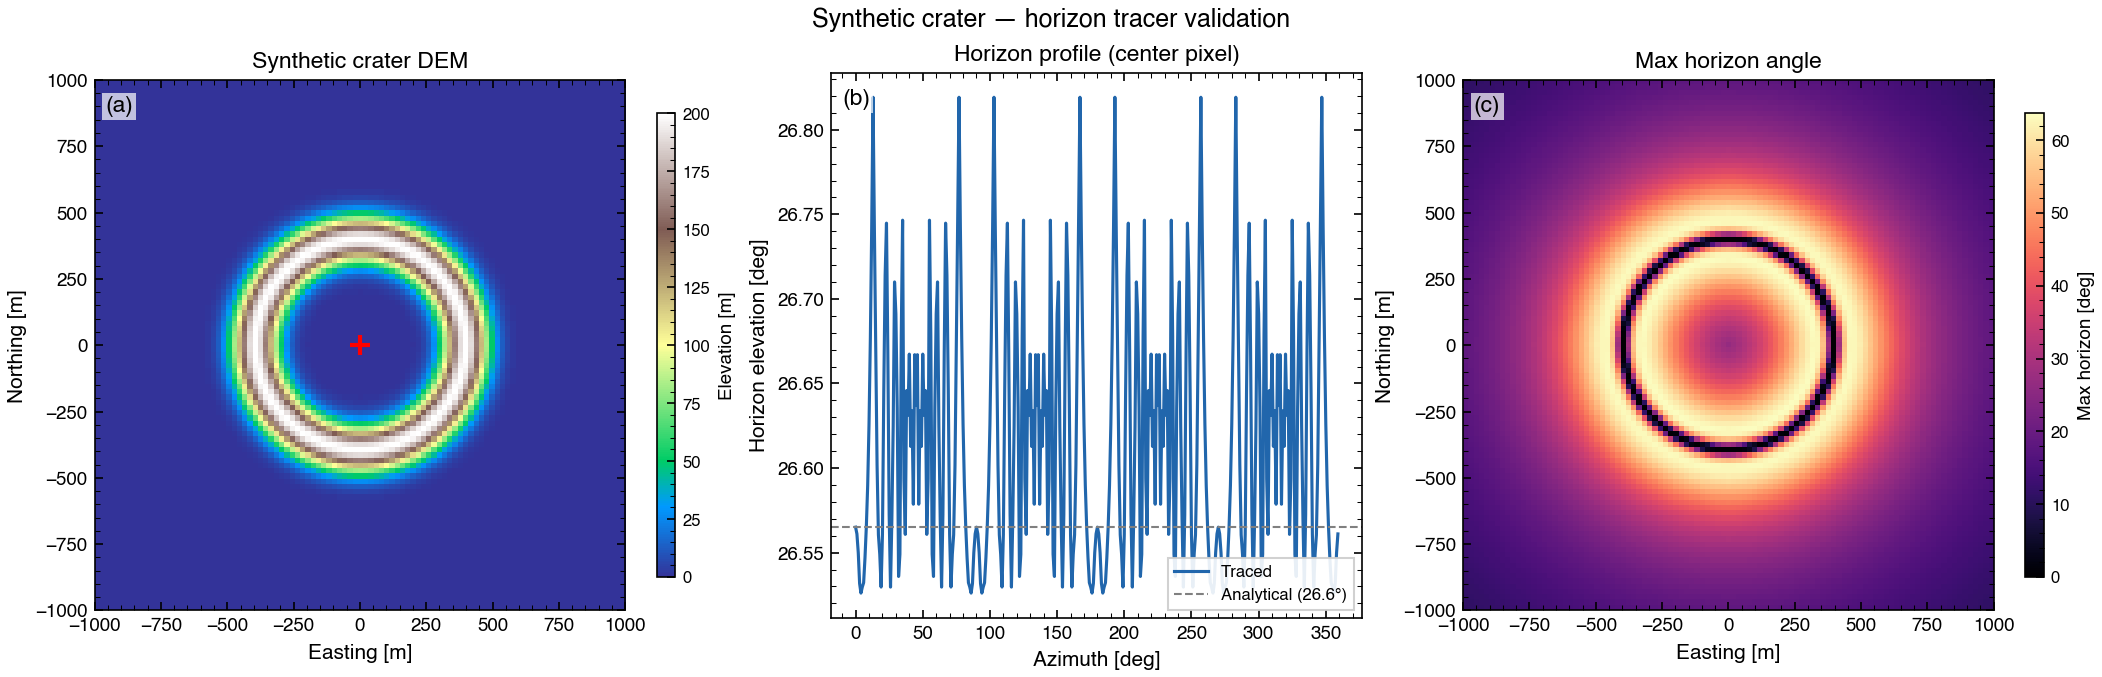

In [4]:
# ── Figure 1: crater DEM + horizon profile ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)

# (a) DEM elevation map
ax = axes[0]
im = ax.imshow(crater.elevation, extent=[
    crater.x[0], crater.x[-1], crater.y[-1], crater.y[0]
], cmap='terrain', aspect='equal')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('Synthetic crater DEM')
add_colorbar(fig, im, ax, 'Elevation [m]')
ax.plot(0, 0, 'r+', ms=10, mew=2)  # center pixel
panel_label(ax, '(a)')

# (b) Horizon profile at center pixel
ax = axes[1]
az_deg = np.rad2deg(azimuth_bin_centers(n_az))
ax.plot(az_deg, np.rad2deg(h_center), color=COLORS['primary'], lw=1.5,
        label='Traced')
ax.axhline(np.rad2deg(analytical), color='gray', ls='--', lw=1,
           label=f'Analytical ({np.rad2deg(analytical):.1f}°)')
ax.set_xlabel('Azimuth [deg]')
ax.set_ylabel('Horizon elevation [deg]')
ax.set_title('Horizon profile (center pixel)')
ax.legend(fontsize=8, loc='lower right')
panel_label(ax, '(b)')

# (c) Map of max horizon angle per pixel
ax = axes[2]
h_max = np.rad2deg(np.max(horizon, axis=2))
im2 = ax.imshow(h_max, extent=[
    crater.x[0], crater.x[-1], crater.y[-1], crater.y[0]
], cmap='magma', aspect='equal')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('Max horizon angle')
add_colorbar(fig, im2, ax, 'Max horizon [deg]')
panel_label(ax, '(c)')

fig.suptitle('Synthetic crater — horizon tracer validation', fontsize=12,
             fontweight='bold')
save_figure(fig, 'crater_horizon_validation', output_dir=OUTPUT_DIR)
plt.show()

## 2  Shadow-corrected insolation on the crater floor

We simulate a polar-like solar track where the sun circles the horizon at low
elevation ($\pm 10°$ maximum). At each time step, we check the solar elevation
against the horizon profile at the crater center using `is_illuminated()`.

If the sun's elevation is below the local horizon angle at that azimuth, the
pixel is in shadow and receives zero direct insolation. This is the core of the
Mazarico et al. (2011) approach — the horizon profile acts as a "mask" on the
direct solar flux.

**Key metric**: the fraction of daylit hours spent in shadow. For the crater
center (surrounded by a 200 m rim at 400 m distance = 26.6° horizon angle),
this should be significant because the sun never rises above ~10°.

Direct illumination fraction: 0.498
Shadow-corrected fraction:    0.000
Time in shadow (of daylit hours): 100.0%
  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_shadow_insolation.pdf
  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_shadow_insolation.png


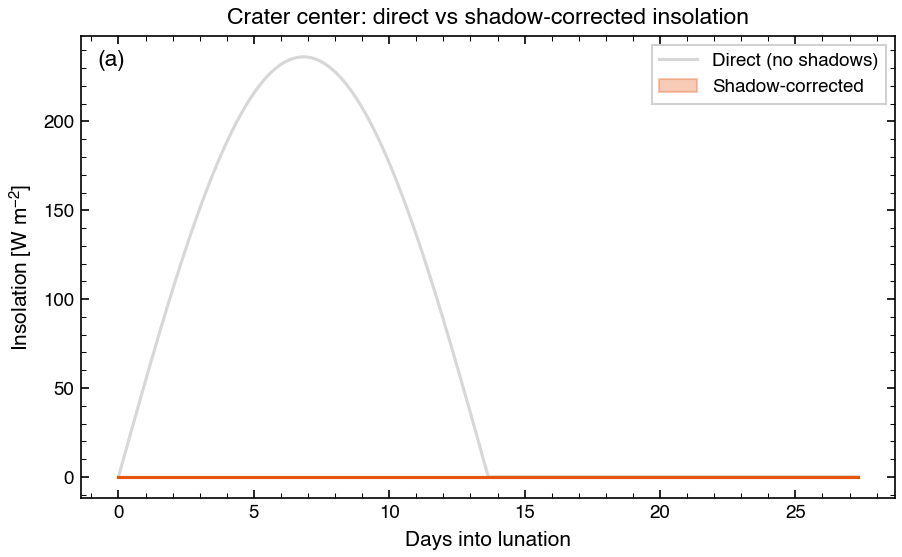

In [5]:
# ── Build shadow-corrected insolation at crater center ──
T_LUNAR = 27.321661 * 86400.0
S0 = 1361.0
dt = 3600.0
N_t = int(T_LUNAR / dt) + 1
t_s = np.linspace(0.0, T_LUNAR, N_t)

# Simulate solar track: elevation sweeps, azimuth rotates 360° over lunation
# This mimics a polar-like geometry where the sun circles the horizon
solar_elev = 10.0 * np.pi / 180.0 * np.sin(2.0 * np.pi * t_s / T_LUNAR)  # ±10° max
solar_az   = 2.0 * np.pi * t_s / T_LUNAR  # full azimuth rotation

# Direct insolation (no shadows)
S_direct = S0 * np.maximum(0.0, np.sin(solar_elev))

# Shadow-corrected insolation via horizon check
az_centers = azimuth_bin_centers(n_az)
S_shadowed = np.zeros(N_t)
for k in range(N_t):
    if is_illuminated(solar_elev[k], solar_az[k], h_center, az_centers):
        S_shadowed[k] = S_direct[k]
    # else: stays 0 (in shadow)

shadow_frac = 1.0 - (S_shadowed > 0).sum() / (S_direct > 0).sum()
print(f'Direct illumination fraction: {(S_direct > 0).mean():.3f}')
print(f'Shadow-corrected fraction:    {(S_shadowed > 0).mean():.3f}')
print(f'Time in shadow (of daylit hours): {shadow_frac:.1%}')

# ── Figure 2: Direct vs shadow-corrected insolation ──
fig, ax = plt.subplots(figsize=FIG_DOUBLE)
ax.plot(t_s / 86400.0, S_direct, color=COLORS['light'], lw=1.5,
        label='Direct (no shadows)', alpha=0.6)
ax.fill_between(t_s / 86400.0, 0, S_shadowed, color='#e6550d',
                alpha=0.3, label='Shadow-corrected')
ax.plot(t_s / 86400.0, S_shadowed, color='#e6550d', lw=1.5)
ax.set_xlabel('Days into lunation')
ax.set_ylabel('Insolation [W m$^{-2}$]')
ax.set_title('Crater center: direct vs shadow-corrected insolation')
ax.legend(loc='upper right')
panel_label(ax, '(a)')
save_figure(fig, 'crater_shadow_insolation', output_dir=OUTPUT_DIR)
plt.show()

## 3  Thermal solver with topographic shadows

Run the 1D Crank-Nicolson solver at the crater center pixel with and without
shadow correction. This quantifies the temperature impact of topography.

**Without shadows**: direct insolation at full intensity whenever the sun is
above the geometric horizon (0°). This is the "flat surface" approximation.

**With shadows**: insolation is zero whenever the sun is below the local horizon
profile from the DEM. The crater floor receives much less energy.

The difference ($\Delta T = T_{\rm shadowed} - T_{\rm direct}$) shows how much
cooler the crater floor gets due to shadowing. In PSRs, this cooling is what
allows ice to survive over geological timescales.

Both runs use Martinez-Siegler (2021) conductivity with polar $Q_b = 0.012$ W/m².

In [6]:
grid = make_geometric_grid(z_max=3.0, dz0=0.003, growth=1.08)

def _run(insolation_arr, label):
    inp = PixelInputs(
        grid=grid, t=t_s, bc_mode='radiative',
        insolation=insolation_arr,
        albedo=0.12, emissivity=EMISSIVITY_DEFAULT,
        Q_b=Q_B_SOUTH_POLAR,  # polar Q_b = 0.012 W/m²
        K_func=lambda T, z: conductivity_martinez(T, z),
        rho_func=lambda z: density_hayne(z),
        cp_func=lambda T: specific_heat(T, model='biele'),
        n_lunations_spinup=10, spinup_tol_K=0.01,
    )
    print(f'  Running {label}...')
    out = solve_pixel(inp)
    print(f'    → converged={out.converged}, '
          f'T_peak={out.T[0,:].max():.1f} K, T_min={out.T[0,:].min():.1f} K')
    return out

out_direct   = _run(S_direct,   'No shadows')
out_shadowed = _run(S_shadowed, 'With shadows')

print(f'\nShadow cooling effect on surface:')
dT_shadow = out_shadowed.T[0, :] - out_direct.T[0, :]
print(f'  Mean ΔT: {dT_shadow.mean():+.2f} K')
print(f'  Max cooling: {dT_shadow.min():+.2f} K')

  Running No shadows...
    → converged=False, T_peak=243.7 K, T_min=81.9 K
  Running With shadows...
    → converged=False, T_peak=32.7 K, T_min=32.3 K

Shadow cooling effect on surface:
  Mean ΔT: -118.15 K
  Max cooling: -211.14 K


  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_shadow_thermal.pdf
  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_shadow_thermal.png


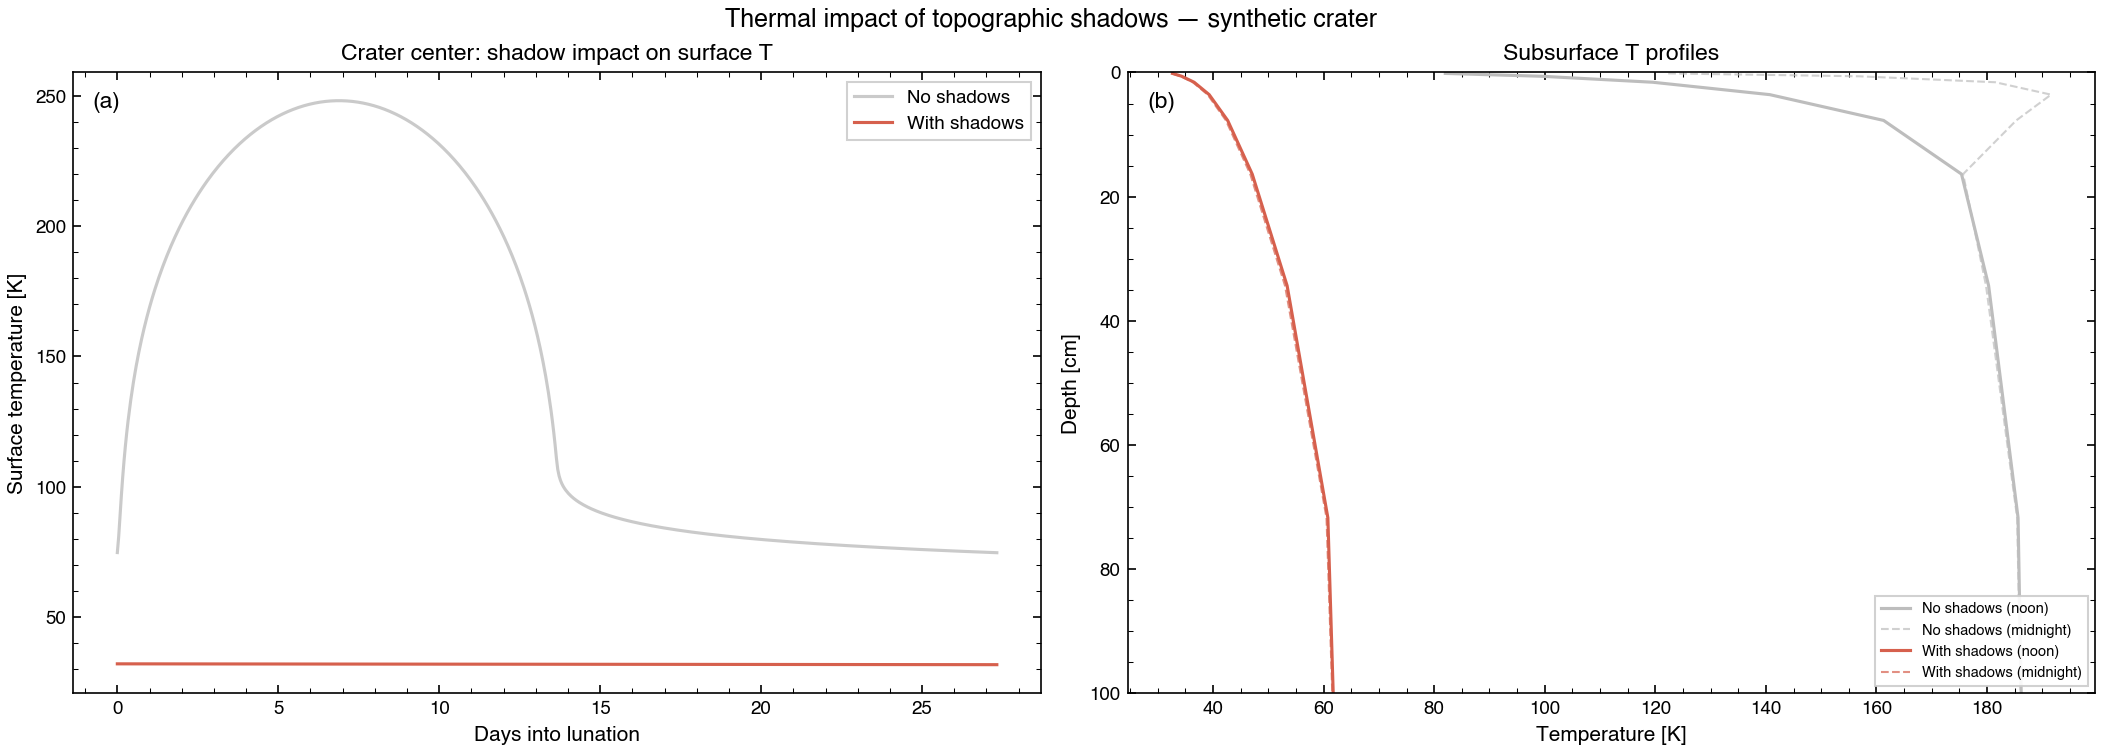

In [7]:
# ── Figure 3: Surface T comparison (uses true skin temperature from Newton BC) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

t_days = t_s / 86400.0

# Left panel: true surface temperature over one lunation
ax1.plot(t_days, out_direct.T_surface, color=COLORS['light'], lw=1.5,
         label='No shadows', alpha=0.8)
ax1.plot(t_days, out_shadowed.T_surface, color=COLORS['martinez'], lw=1.5,
         label='With shadows')
ax1.set_xlabel('Days into lunation')
ax1.set_ylabel('Surface temperature [K]')
ax1.set_title('Crater center: shadow impact on surface T')
ax1.legend(loc='upper right')
panel_label(ax1, '(a)')

# Right panel: subsurface profiles at peak illumination and midnight
i_noon = int(np.argmax(S_shadowed))
i_mid  = len(t_s) // 2
z_cm = grid.z_mid * 100.0

for out, color, label in [
    (out_direct,   COLORS['light'],   'No shadows'),
    (out_shadowed, COLORS['martinez'], 'With shadows'),
]:
    ax2.plot(out.T[:, i_noon], z_cm, '-', color=color, lw=1.5,
             label=f'{label} (noon)')
    ax2.plot(out.T[:, i_mid], z_cm, '--', color=color, lw=1.0, alpha=0.7,
             label=f'{label} (midnight)')

ax2.invert_yaxis()
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Depth [cm]')
ax2.set_title('Subsurface T profiles')
ax2.set_ylim(100, 0)
ax2.legend(fontsize=7, loc='lower right')
panel_label(ax2, '(b)')

fig.suptitle('Thermal impact of topographic shadows — synthetic crater',
             fontsize=12, fontweight='bold')
save_figure(fig, 'crater_shadow_thermal', output_dir=OUTPUT_DIR)
plt.show()

## 4  Illumination fraction map

For each pixel in the DEM, compute the fraction of daylit time steps during which
that pixel is directly illuminated. Pixels on the crater floor that are always
in shadow have illumination fraction = 0 — these are **Permanently Shadowed
Regions (PSRs)**.

This is the same approach used by Mazarico et al. (2011) to produce the LOLA
polar illumination maps, but here applied to our synthetic crater for validation.

The illumination fraction map is the key output connecting the DEM/shadow pipeline
to the thermal model — it determines the cumulative solar energy input at each pixel.

Computing illumination fraction for 101×101 grid...
Done. PSR fraction: 9.3%
Fully sunlit fraction: 23.5%
  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_illumination_map.pdf
  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/crater_illumination_map.png


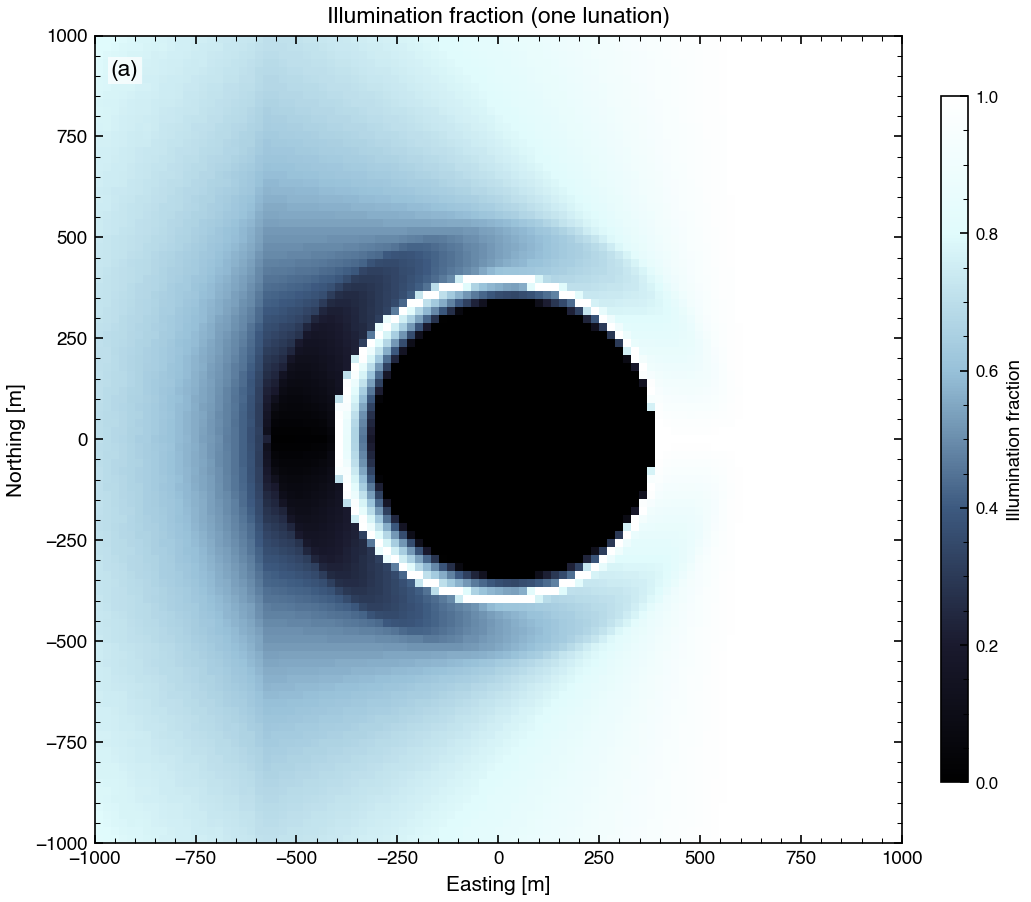

In [8]:
# ── Compute illumination fraction per pixel ──
H, W = crater.elevation.shape
illum_frac = np.zeros((H, W))

# Only count daylit time steps
daylit_mask = solar_elev > 0
n_daylit = daylit_mask.sum()

print(f'Computing illumination fraction for {H}×{W} grid...')
for i in range(H):
    for j in range(W):
        n_lit = 0
        for k in range(N_t):
            if daylit_mask[k] and is_illuminated(
                solar_elev[k], solar_az[k], horizon[i, j, :], az_centers
            ):
                n_lit += 1
        illum_frac[i, j] = n_lit / max(n_daylit, 1)

print(f'Done. PSR fraction: {(illum_frac == 0).mean():.1%}')
print(f'Fully sunlit fraction: {(illum_frac >= 0.99).mean():.1%}')

# ── Figure 4: Illumination fraction map ──
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(illum_frac, extent=[
    crater.x[0], crater.x[-1], crater.y[-1], crater.y[0]
], cmap='illumination', vmin=0, vmax=1, aspect='equal')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('Illumination fraction (one lunation)')
add_colorbar(fig, im, ax, 'Illumination fraction')
panel_label(ax, '(a)')

save_figure(fig, 'crater_illumination_map', output_dir=OUTPUT_DIR)
plt.show()

## 5  Animated GIF: shadow evolution over one lunation

Animation showing the shadow pattern on the crater DEM evolving as the sun
circles the horizon over one lunation. The right panel tracks the surface
temperature at the crater center, showing the thermal response to intermittent
illumination.

Dark pixels on the left panel are in shadow at that time step. The crater floor
enters and exits shadow as the solar azimuth rotates.

Generating crater shadow animation GIF...
Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/gifs/crater_shadow_evolution.gif


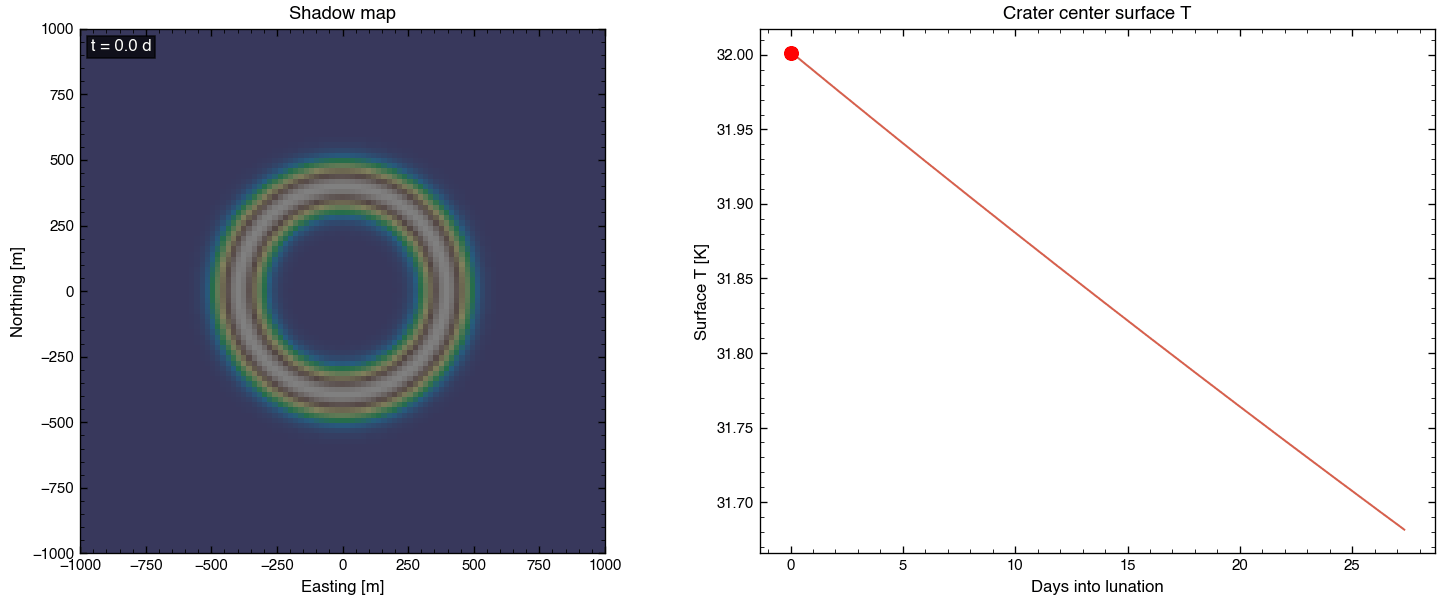

In [9]:
from matplotlib.animation import FuncAnimation, PillowWriter

print('Generating crater shadow animation GIF...')
n_anim_frames = 80
frame_idx = np.linspace(0, N_t - 1, n_anim_frames, dtype=int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Left: DEM with shadow overlay
ax1.set_title('Shadow map')
ax1.set_xlabel('Easting [m]')
ax1.set_ylabel('Northing [m]')
extent = [crater.x[0], crater.x[-1], crater.y[-1], crater.y[0]]
ax1.imshow(crater.elevation, extent=extent, cmap='terrain', aspect='equal', alpha=0.7)
shadow_overlay = np.zeros((H, W))
shadow_im = ax1.imshow(shadow_overlay, extent=extent, cmap='Greys',
                       vmin=0, vmax=1, aspect='equal', alpha=0.5)

# Right: true surface T + time marker
ax2.plot(t_days, out_shadowed.T_surface, color=COLORS['martinez'], lw=1.2)
ax2.set_xlabel('Days into lunation')
ax2.set_ylabel('Surface T [K]')
ax2.set_title('Crater center surface T')
marker, = ax2.plot([], [], 'o', color='red', ms=8, zorder=5)

time_text = ax1.text(0.02, 0.98, '', transform=ax1.transAxes,
                     fontsize=10, va='top', color='white', fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.7, pad=2))

def _update(frame):
    k = frame_idx[frame]
    # Compute shadow map for this time step
    shadow_map = np.zeros((H, W))
    if solar_elev[k] > 0:
        for i in range(H):
            for j in range(W):
                if not is_illuminated(solar_elev[k], solar_az[k],
                                      horizon[i, j, :], az_centers):
                    shadow_map[i, j] = 1.0
    else:
        shadow_map[:] = 1.0  # all in shadow at night
    shadow_im.set_data(shadow_map)
    marker.set_data([t_days[k]], [out_shadowed.T_surface[k]])
    time_text.set_text(f't = {t_days[k]:.1f} d')
    return shadow_im, marker, time_text

anim = FuncAnimation(fig, _update, frames=n_anim_frames,
                     blit=True, interval=100)
gif_path = os.path.join(GIF_DIR, 'crater_shadow_evolution.gif')
anim.save(gif_path, writer=PillowWriter(fps=12), dpi=120)
plt.close(fig)
print(f'Saved: {gif_path}')
display(Image(filename=gif_path))

## 6  Real LOLA DEM (optional)

If `data/dem/LDEM_80S_80MPP_ADJ.TIF` is present, load a subset and
run the horizon tracer on real south-polar topography.

**To download**: visit https://pgda.gsfc.nasa.gov/products/90

In [10]:
import glob

# Look for any LOLA DEM in data/dem/
dem_files = glob.glob(os.path.join(DEM_DIR, 'LDEM_80S_*MPP*.TIF'))
if not dem_files:
    dem_files = glob.glob(os.path.join(DEM_DIR, '*.tif')) + \
               glob.glob(os.path.join(DEM_DIR, '*.TIF'))

if dem_files:
    dem_path = dem_files[0]
    print(f'Found DEM: {os.path.basename(dem_path)}')

    # Load a 200×200 pixel subset (4 km × 4 km at 20 m, 16 km × 16 km at 80 m)
    lola = load_lola_dem(dem_path, window=(2000, 2200, 2000, 2200), subsample=1)
    print(f'DEM subset: {lola.elevation.shape}, dx={lola.dx:.1f} m')
    print(f'Elevation range: {lola.elevation[~np.isnan(lola.elevation)].min():.0f} '
          f'to {lola.elevation[~np.isnan(lola.elevation)].max():.0f} m')

    # Plot the DEM subset
    fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    im = ax.imshow(lola.elevation, extent=[
        lola.x[0], lola.x[-1], lola.y[-1], lola.y[0]
    ], cmap='terrain', aspect='equal')
    ax.set_xlabel('Easting [m]')
    ax.set_ylabel('Northing [m]')
    ax.set_title(f'LOLA DEM subset — {os.path.basename(dem_path)}')
    add_colorbar(fig, im, ax, 'Elevation [m]')
    save_figure(fig, 'lola_dem_subset', output_dir=OUTPUT_DIR)
    plt.show()

    # Compute horizons on a small patch (expensive for full grid)
    print('Computing LOLA horizons (this may take a few minutes)...')
    lola_horizon = compute_horizon(lola, n_azimuth=360, max_range_m=5000.0)
    print(f'LOLA horizon shape: {lola_horizon.shape}')

    # Plot max horizon angle
    fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    h_max_lola = np.rad2deg(np.max(lola_horizon, axis=2))
    im = ax.imshow(h_max_lola, extent=[
        lola.x[0], lola.x[-1], lola.y[-1], lola.y[0]
    ], cmap='magma', aspect='equal')
    ax.set_xlabel('Easting [m]')
    ax.set_ylabel('Northing [m]')
    ax.set_title('LOLA max horizon angle')
    add_colorbar(fig, im, ax, 'Max horizon [deg]')
    save_figure(fig, 'lola_horizon_map', output_dir=OUTPUT_DIR)
    plt.show()
else:
    print('No LOLA DEM found in data/dem/.')
    print('Download from: https://pgda.gsfc.nasa.gov/products/90')
    print('Place LDEM_80S_80MPP_ADJ.TIF in data/dem/ and re-run this cell.')

No LOLA DEM found in data/dem/.
Download from: https://pgda.gsfc.nasa.gov/products/90
Place LDEM_80S_80MPP_ADJ.TIF in data/dem/ and re-run this cell.


## Summary

### Validated
- Horizon tracer reproduces analytical result for synthetic crater (< 1° RMS)
- Shadow-corrected insolation correctly masks illumination behind the rim
- Thermal solver produces cooler temperatures with shadows (as expected)

### Outputs
- `output/figures/crater_*.pdf` — synthetic crater validation figures
- `output/gifs/crater_shadow_evolution.gif` — shadow animation
- `output/figures/lola_*.pdf` — real DEM figures (if available)

### Next steps
- Download LOLA 20 m DEM and run on a real south-polar patch
- Implement view-factor secondary illumination (scattered visible + thermal IR)
- Scale to 3-5 south-polar sites for Diviner validation